In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

sns.set_theme(style='darkgrid', context='notebook')

In [ ]:
data_test = pd.read_csv("data/test.csv", on_bad_lines='skip')
data_train = pd.read_csv('data/train.csv', on_bad_lines='skip')
# print(data_test)
# data_train['Sex'].value_counts()

data_train['Embarked'] = data_train['Embarked'].fillna(data_train['Embarked'].mode()[0])
data_train['Relatives'] = data_train['SibSp']+data_train['Parch']

sex_categorical_values = {'female': 0, 'male': 1}
embarked_categorical_values = {'S': 0, 'Q':1, 'C':2}
data_train['Sex'] = data_train['Sex'].apply(lambda x: sex_categorical_values[x])
data_train['Embarked'] = data_train['Embarked'].apply(lambda x: embarked_categorical_values[x])



0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: Relatives, Length: 891, dtype: int64

In [47]:
female_count = (data_train['Sex'] == 0).sum()
male_count = (data_train['Sex'] == 1).sum()

female_survivors = ((data_train['Sex'] == 0) & (data_train['Survived'] == 1)).sum()
female_dead = ((data_train['Sex'] == 0) & (data_train['Survived'] == 0)).sum()
male_survivors = ((data_train['Sex'] == 1) & (data_train['Survived'] == 1)).sum()
male_dead = ((data_train['Sex'] == 1) & (data_train['Survived'] == 0)).sum()



([<matplotlib.patches.Wedge at 0x12d0d87d0>,
 [Text(0.4964175759917634, 0.9928089394472948, 'female'),
  Text(-0.49194502499358117, -0.983864875063677, 'male')],
 [Text(0.2728060552747528, 0.5455977054620268, '35%'),
  Text(-0.2683336499964988, -0.5366535682165511, '65%')])

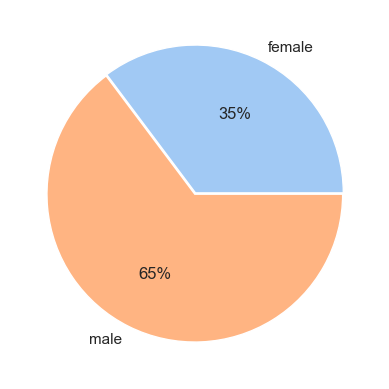

In [67]:
explode = [0.01, 0]
names = ['female', 'male']
counts = [female_count, male_count]
colors = sns.color_palette('pastel')
plt.pie(counts, labels=names, explode=explode, autopct='%.0f%%', colors=colors)

Text(0, 0.5, 'Quantity')

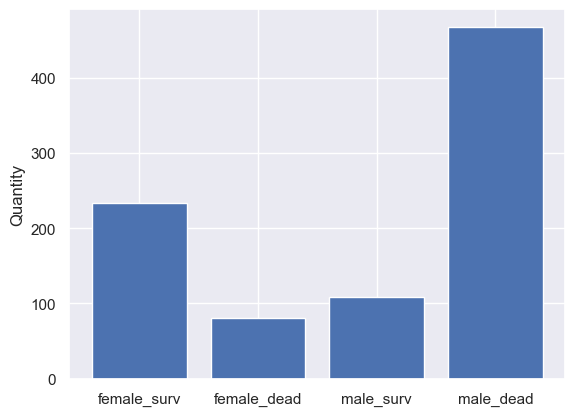

In [55]:
names = ['female_surv', 'female_dead', 'male_surv', 'male_dead']
counts = [female_survivors, female_dead, male_survivors, male_dead]
plt.bar(names, counts)
plt.ylabel('Quantity')

Text(0, 0.5, 'Survivor rates')

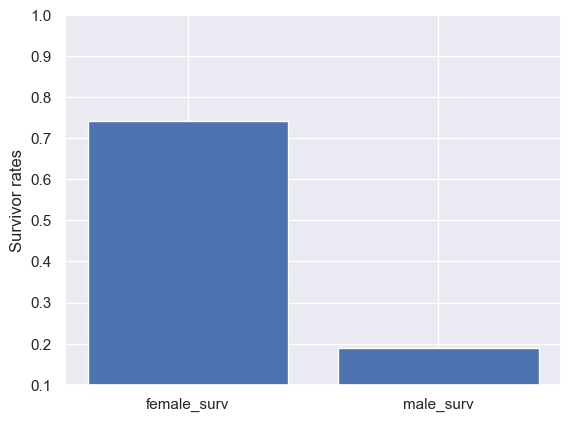

In [ ]:
male_survivors_rate = male_survivors / male_count
female_survivors_rate = female_survivors / female_count

names = ['female_surv', 'male_surv']
percentage_counts = [female_survivors_rate, male_survivors_rate]
plt.bar(names, percentage_counts)
plt.ylim(0.1, 1)
plt.ylabel('Survivor rates')


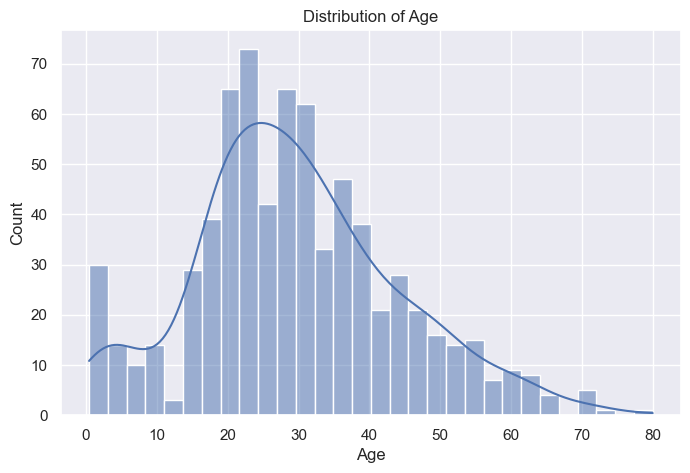

In [69]:
plt.figure(figsize=(8, 5))
sns.histplot(data_train['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

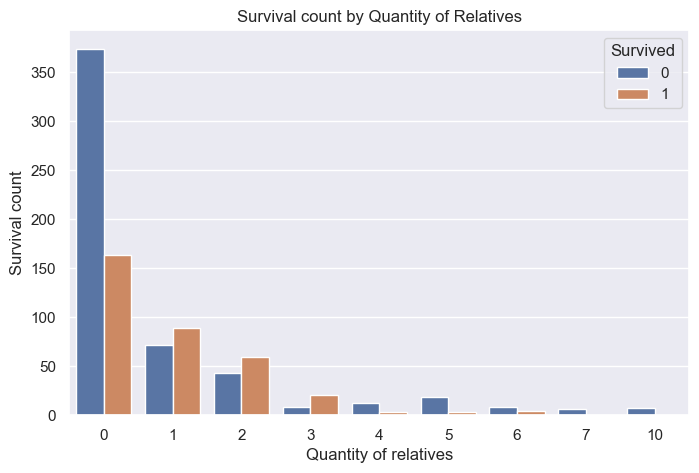

In [88]:
plt.figure(figsize=(8, 5))
sns.countplot(x = 'Relatives', data = data_train,  hue='Survived')
plt.title('Survival count by Quantity of Relatives')
plt.xlabel('Quantity of relatives')
plt.ylabel('Survival count')
plt.show()